# Time Series Modelling Case Study
##Forecasting German Electricity Demand Using Statistical, Machine Learning, and Deep Learning Techniques

#Module: Advanced Research Topics

#Objectives

This case study aims to develop and evaluate forecasting models for German electricity demand by applying a range of time-series forecasting approaches. Traditional statistical techniques, machine learning algorithms, and deep learning models are compared to assess their forecasting performance and identify the most reliable method for short- and medium-term electricity demand prediction.

#The study is organised into the following stages:



* Collection and preparation of electricity demand data
* Exploratory data analysis (EDA) and data visualisation
* Assessment of stationarity and data transformation
* Development of baseline forecasting models
* Implementation of SARIMA and SARIMAX models
* Construction of feature-based machine learning models
* Development of Long Short-Term Memory (LSTM) networks
* Evaluation and comparison of model performance using forecasting accuracy metrics
* Interpretation of results, discussion of findings, and final recommendations

Import Required Libraries

In [1]:
# Core Libraries

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import tensorflow as tf

# Data Visualization

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")


# Time Series Analysis


from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from statsmodels.tsa.stattools import (
    adfuller,
    kpss
)

# Utilities

import requests

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("Libraries imported successfully.")

Libraries imported successfully.


# Data Collection

The German electricity demand data is obtained from the Open Power System Data (OPSD) project.

Dataset:

- Hourly electricity demand
- Country: Germany (DE)
- Period: January 2015 to October 2020


In [2]:
# Load German Electricity Demand Dataset

data_link = (
    "https://data.open-power-system-data.org/"
    "time_series/2020-10-06/"
    "time_series_60min_singleindex.csv"
)

electricity_data = pd.read_csv(
    data_link,
    usecols=[
        "utc_timestamp",
        "DE_load_actual_entsoe_transparency"
    ],
    parse_dates=["utc_timestamp"]
)

# Rename columns for simplicity
electricity_data = electricity_data.rename(
    columns={
        "utc_timestamp": "datetime",
        "DE_load_actual_entsoe_transparency": "electricity_load_mw"
    }
)

# Set datetime as index
electricity_data = electricity_data.set_index("datetime")

# Arrange records in chronological order
electricity_data = electricity_data.sort_index()

print(f"Dataset Dimensions: {electricity_data.shape}")

electricity_data.head()

Dataset Dimensions: (50401, 1)


,electricity_load_mw
datetime,
2014-12-31 23:00:00+00:00,NaN
2015-01-01 00:00:00+00:00,41151.0
2015-01-01 01:00:00+00:00,40135.0
2015-01-01 02:00:00+00:00,39106.0
2015-01-01 03:00:00+00:00,38765.0


The original data is provided in megawatts (MW) and later converted into gigawatts (GW) after aggregation.

# Data Cleaning

The raw dataset contains missing observations and covers a much longer historical period than required.

The following preprocessing steps are performed:

- Remove missing observations
- Convert the load values to numeric format
- Restrict the study period to January 2015 onwards
- Inspect the resulting dataset

In [3]:
# Data Cleaning

load = electricity_data["electricity_load_mw"].astype(float)
print("Missing values before cleaning :", load.isna().sum())

load = load.dropna()
load = load["2015-01-01":]

print("\nDataset after cleaning")
print(f"Observations : {len(load):,}")
print(f"Start Date   : {load.index.min()}")
print(f"End Date     : {load.index.max()}")
print(f"\nMissing Values : {load.isna().sum()}")
load.head()

Missing values before cleaning : 1

Dataset after cleaning
Observations : 50,400
Start Date   : 2015-01-01 00:00:00+00:00
End Date     : 2020-09-30 23:00:00+00:00

Missing Values : 0


,electricity_load_mw
datetime,
2015-01-01 00:00:00+00:00,41151.0
2015-01-01 01:00:00+00:00,40135.0
2015-01-01 02:00:00+00:00,39106.0
2015-01-01 03:00:00+00:00,38765.0
2015-01-01 04:00:00+00:00,38941.0


# Data Aggregation

The original dataset contains electricity demand measurements at an hourly frequency. To facilitate time-series analysis, the data are resampled into lower-frequency time intervals:

* Daily average electricity demand
* Weekly average electricity demand

The weekly aggregated series is selected for the majority of the analysis, as it smooths short-term fluctuations and highlights longer-term trends and seasonal behaviour, making it more suitable for forecasting.

In [4]:
# Aggregate Data

daily = load.resample("D").mean() / 1000
weekly = load.resample("W").mean() / 1000
daily = daily.interpolate("time")
weekly = weekly.interpolate("time")

daily.name = "load_gw"
weekly.name = "load_gw"

print("Daily observations :", len(daily))
print("Weekly observations :", len(weekly))

weekly.head()

Daily observations : 2100
Weekly observations : 301


,load_gw
datetime,
2015-01-04 00:00:00+00:00,47.233740
2015-01-11 00:00:00+00:00,56.191101
2015-01-18 00:00:00+00:00,57.672679
2015-01-25 00:00:00+00:00,58.613304
2015-02-01 00:00:00+00:00,58.734030


In [5]:
summary = pd.DataFrame({

    "Statistic": [
        "Minimum",
        "Maximum",
        "Mean",
        "Median",
        "Standard Deviation"
    ],

    "Value (GW)": [
        weekly.min(),
        weekly.max(),
        weekly.mean(),
        weekly.median(),
        weekly.std()
    ]

})

summary

,Statistic,Value (GW)
0,Minimum,46.505310
1,Maximum,63.587012
2,Mean,55.484350
3,Median,54.858435
4,Standard Deviation,3.762742


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the behaviour of the electricity demand series before building forecasting models.

Daily Electricity Demand

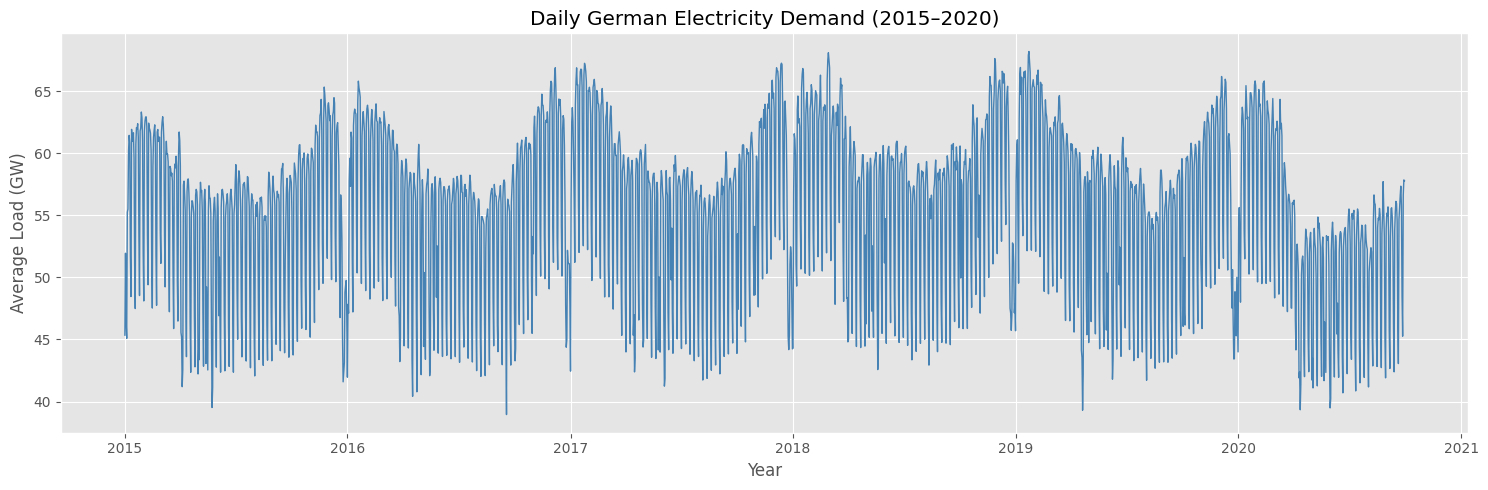

In [6]:
# Daily Electricity Demand

plt.figure(figsize=(15,5))

plt.plot(
    daily.index,
    daily,
    color="steelblue",
    linewidth=1
)

plt.title("Daily German Electricity Demand (2015–2020)")
plt.xlabel("Year")
plt.ylabel("Average Load (GW)")

plt.tight_layout()
plt.show()

Weekly Electricity Demand

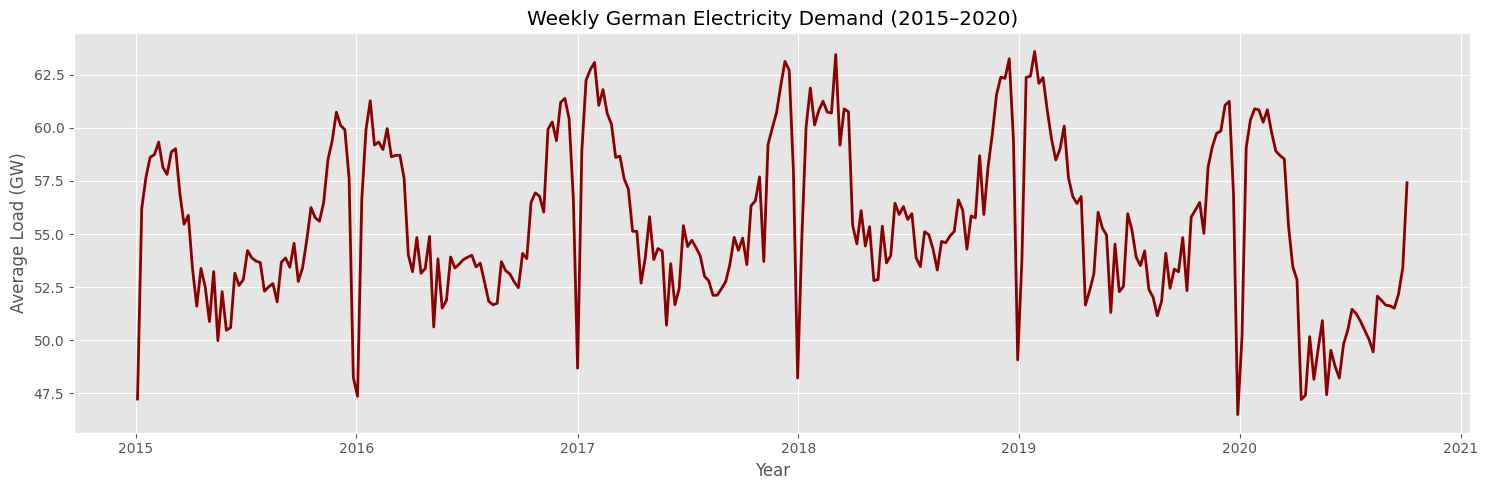

In [7]:
# Weekly Electricity Demand

plt.figure(figsize=(15,5))

plt.plot(
    weekly.index,
    weekly,
    color="darkred",
    linewidth=2
)

plt.title("Weekly German Electricity Demand (2015–2020)")
plt.xlabel("Year")
plt.ylabel("Average Load (GW)")

plt.tight_layout()
plt.show()

### Interpretation

The weekly aggregation produces a smoother time series by reducing short-term fluctuations that are present in the hourly and daily observations.

This makes long-term trend and annual seasonal patterns easier to identify, which is beneficial for forecasting models such as SARIMA and SARIMAX.

Distribution of Weekly Demand

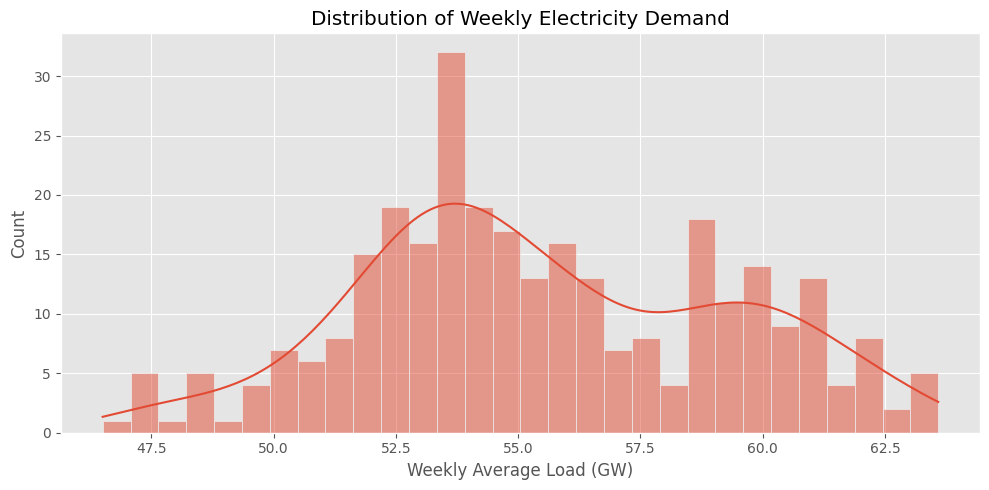

In [8]:
# Distribution of Weekly Demand

plt.figure(figsize=(10,5))

sns.histplot(
    weekly,
    bins=30,
    kde=True
)

plt.title("Distribution of Weekly Electricity Demand")
plt.xlabel("Weekly Average Load (GW)")

plt.tight_layout()
plt.show()

Rolling Statistics

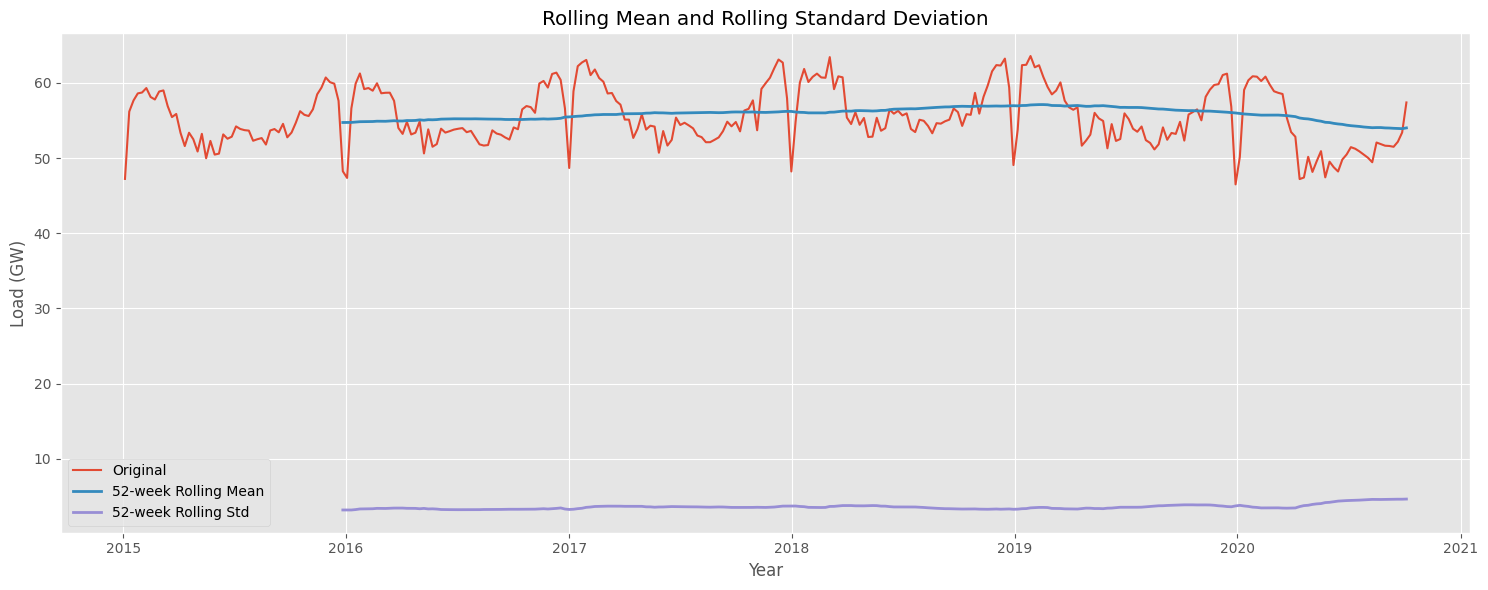

In [9]:
# Rolling Statistics

rolling_mean = weekly.rolling(window=52).mean()
rolling_std = weekly.rolling(window=52).std()

plt.figure(figsize=(15,6))

plt.plot(
    weekly,
    label="Original",
    linewidth=1.5
)

plt.plot(
    rolling_mean,
    label="52-week Rolling Mean",
    linewidth=2
)

plt.plot(
    rolling_std,
    label="52-week Rolling Std",
    linewidth=2
)

plt.title("Rolling Mean and Rolling Standard Deviation")

plt.xlabel("Year")

plt.ylabel("Load (GW)")

plt.legend()

plt.tight_layout()

plt.show()

### Interpretation

Rolling statistics provide a visual assessment of stationarity.

If the rolling mean and rolling standard deviation change substantially over time, the series is likely to be non-stationary. Such behaviour suggests that transformations such as differencing may be required before fitting statistical forecasting models.

# Time Series Decomposition

Time series decomposition separates the electricity demand series into three components:

- **Trend:** Overall long-term movement.
- **Seasonal:** Recurring yearly patterns.
- **Residual:** Random variations not explained by the trend or seasonality.

Since the data are aggregated weekly, a seasonal period of 52 weeks is used to capture annual seasonal behaviour.

Seasonal Decomposition

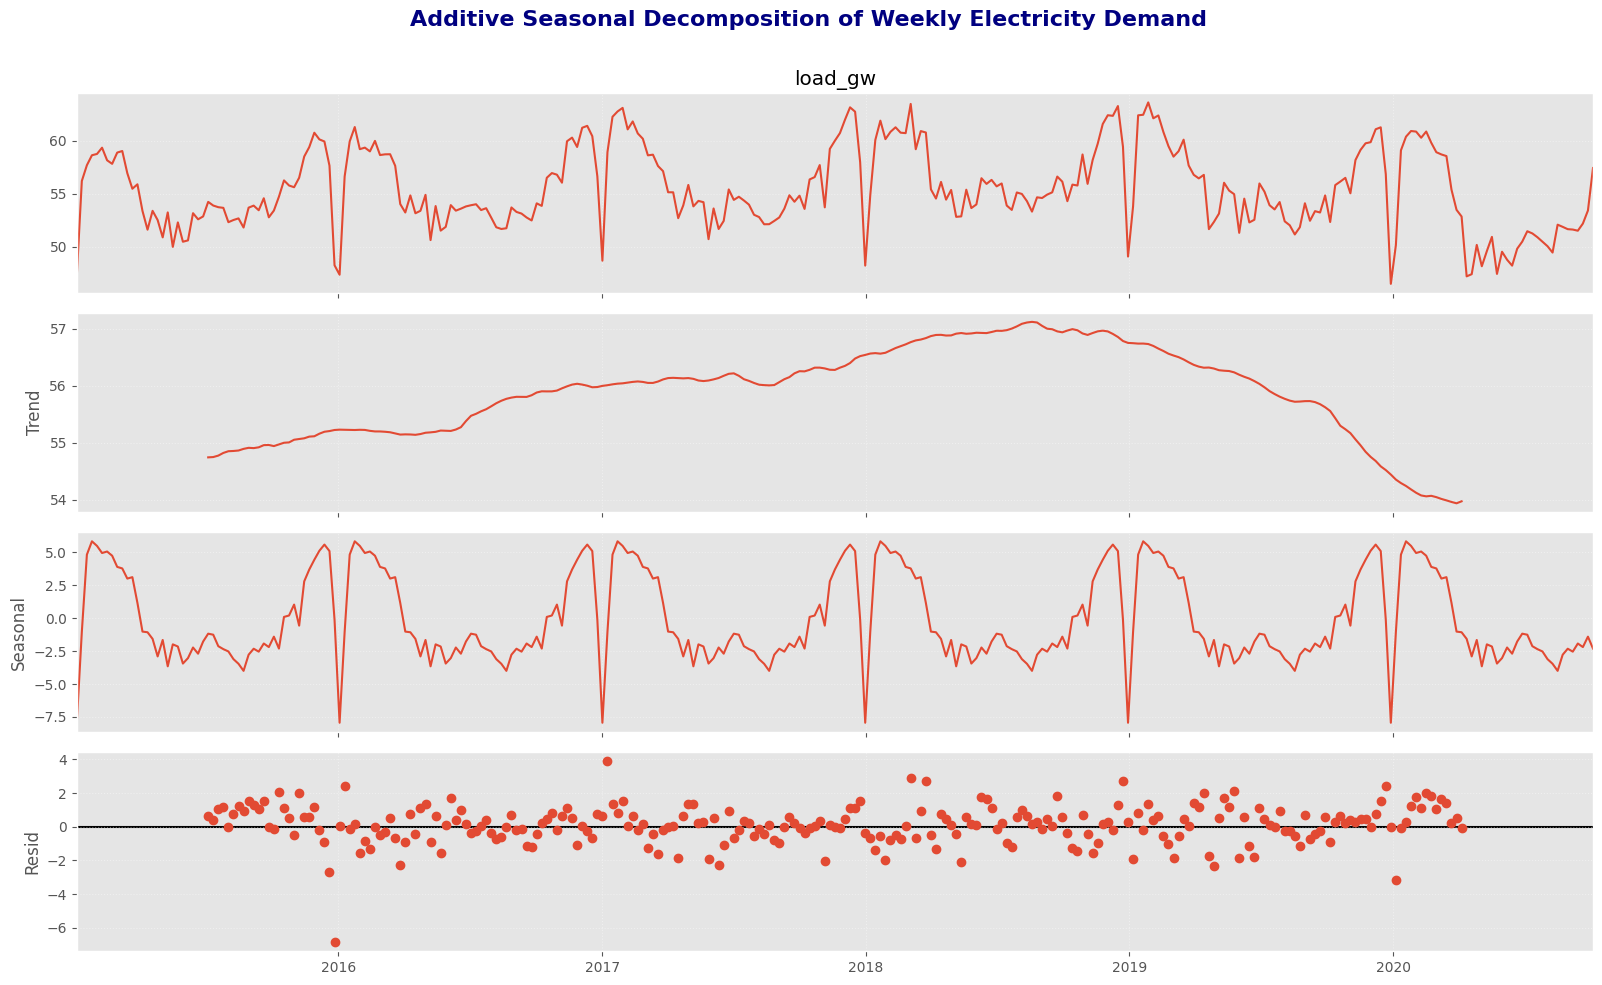

In [10]:
# Seasonal Time Series Decomposition

from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(
    weekly,
    model="additive",
    period=52
)

figure = result.plot()

figure.set_size_inches(16, 10)

# Improve plot appearance
for ax in figure.axes:
    ax.grid(True, linestyle=":", alpha=0.4)
    ax.set_xlabel("")

figure.suptitle(
    "Additive Seasonal Decomposition of Weekly Electricity Demand",
    fontsize=16,
    fontweight="bold",
    color="navy"
)

plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.show()

### Interpretation

The decomposition reveals the three fundamental components of the weekly electricity demand series.

- The **trend component** shows gradual changes in average electricity demand over the study period.
- The **seasonal component** exhibits a strong and consistent annual cycle, confirming the presence of yearly seasonality.
- The **residual component** captures the irregular variation that remains after removing both trend and seasonal effects.

The presence of a clear seasonal pattern supports the use of seasonal forecasting models such as **SARIMA** and **SARIMAX**, rather than non-seasonal ARIMA models.

# Autocorrelation Analysis

Autocorrelation measures the relationship between observations separated by different time lags.

Two diagnostic plots are commonly used:

- **Autocorrelation Function (ACF):** Identifies persistence and possible moving-average (MA) behaviour.
- **Partial Autocorrelation Function (PACF):** Helps determine autoregressive (AR) behaviour.

These plots provide an initial indication of suitable model orders for SARIMA.

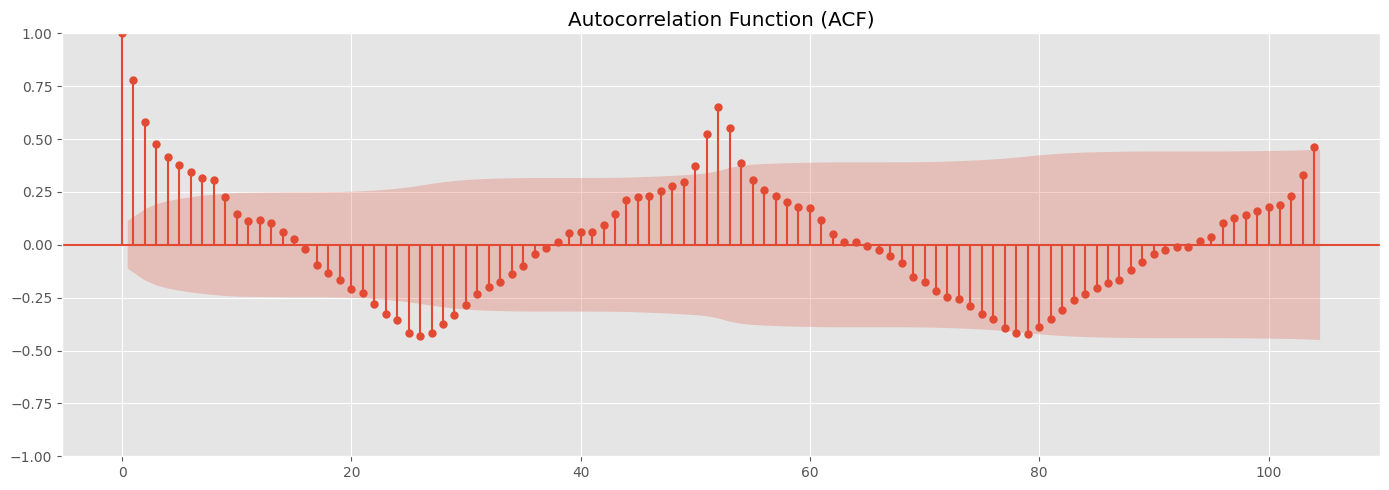

In [11]:
# Autocorrelation Function (ACF)

plt.figure(figsize=(14,5))

plot_acf(
    weekly,
    lags=104,
    ax=plt.gca()
)

plt.title("Autocorrelation Function (ACF)")

plt.tight_layout()

plt.show()

PACF Plot

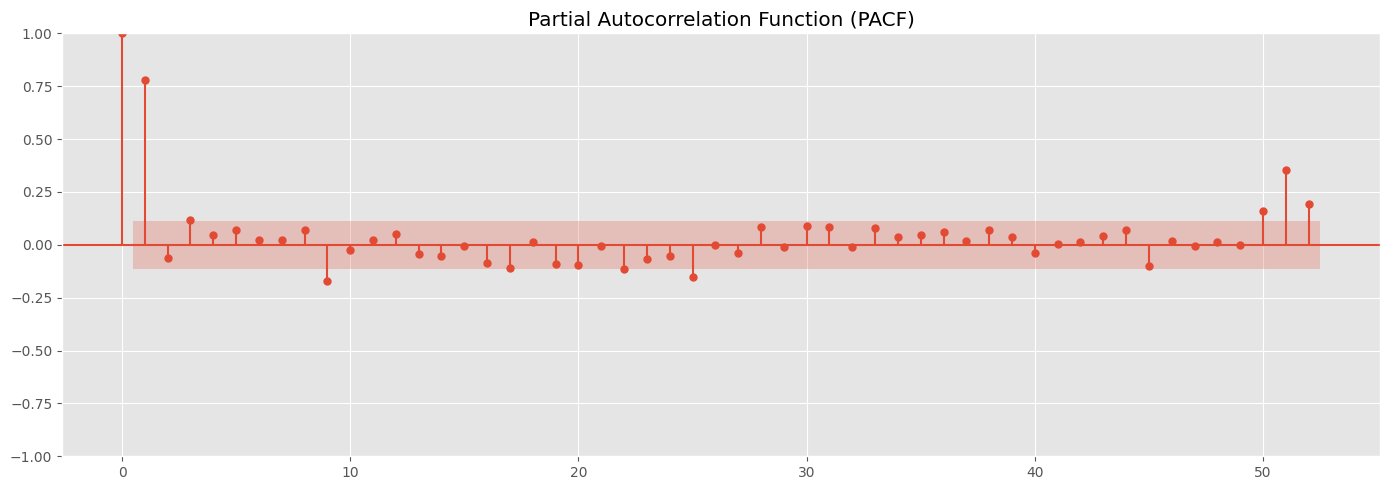

In [12]:
# Partial Autocorrelation Function (PACF)

plt.figure(figsize=(14,5))

plot_pacf(
    weekly,
    lags=52,
    method="ywm",
    ax=plt.gca()
)

plt.title("Partial Autocorrelation Function (PACF)")

plt.tight_layout()

plt.show()

ADF Test

In [13]:
# Augmented Dickey-Fuller Test
from statsmodels.tsa.stattools import adfuller
adf_result = adfuller(weekly)

print("Augmented Dickey-Fuller Test")
print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"p-value       : {adf_result[1]:.4f}")
print(f"Lags Used     : {adf_result[2]}")
print(f"Observations  : {adf_result[3]}")
print("\nCritical Values")

for key, value in adf_result[4].items():
    print(f"{key}: {value:.4f}")

Augmented Dickey-Fuller Test
ADF Statistic : -4.0475
p-value       : 0.0012
Lags Used     : 8
Observations  : 292

Critical Values
1%: -3.4529
5%: -2.8715
10%: -2.5721


KPSS Test

In [14]:
# KPSS Test

from statsmodels.tsa.stattools import kpss

print("KPSS Test")

kpss_result = kpss(
    weekly,
    regression="c",
    nlags="auto"
)

print(f"KPSS Statistic : {kpss_result[0]:.4f}")
print(f"p-value        : {kpss_result[1]:.4f}")
print(f"Lags Used      : {kpss_result[2]}")

print("\nCritical Values")

for key, value in kpss_result[3].items():
    print(f"{key}: {value:.4f}")

KPSS Test
KPSS Statistic : 0.1604
p-value        : 0.1000
Lags Used      : 9

Critical Values
10%: 0.3470
5%: 0.4630
2.5%: 0.5740
1%: 0.7390


/tmp/ipykernel_1469/3266816341.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(


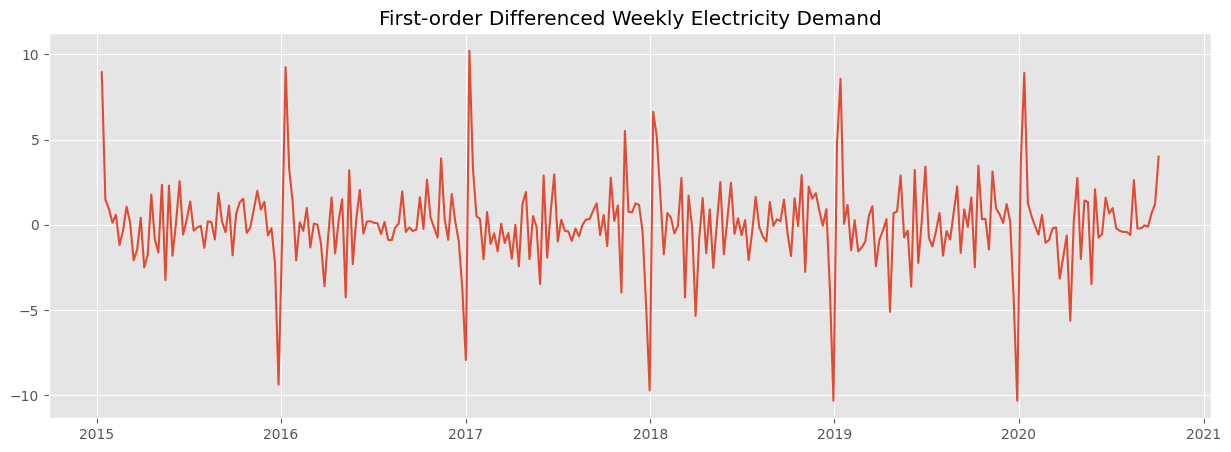

In [15]:
weekly_diff = weekly.diff()

plt.figure(figsize=(15,5))
plt.plot(weekly_diff)
plt.title("First-order Differenced Weekly Electricity Demand")
plt.show()

The ADF and KPSS tests both indicated that the weekly electricity demand series was already stationary. Therefore, additional differencing was not required for stationarity testing. Nevertheless, the SARIMA model selected through AIC included first-order and seasonal differencing because this specification produced the best model fit and forecasting performance.

# Benchmark Forecasting Models

Benchmark forecasting models provide a simple baseline against which more advanced forecasting methods can be compared.

The following benchmark models are implemented:

- Mean Forecast
- Naïve Forecast
- Seasonal Naïve Forecast
- Drift Forecast

The final **104 weeks (2 years)** are used as the test period, as specified in the assignment.

Train-Test Split

In [17]:
# Train-Test Split


test_weeks = 104

train = weekly.iloc[:-test_weeks]
test = weekly.iloc[-test_weeks:]

print(f"Training period : {train.index.min().date()} to {train.index.max().date()}")
print(f"Testing period  : {test.index.min().date()} to {test.index.max().date()}")

h = len(test)

Training period : 2015-01-04 to 2018-10-07
Testing period  : 2018-10-14 to 2020-10-04


Evaluation Functions

In [18]:
# Evaluation Functions

import numpy as np
import pandas as pd

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

def rmse(y_true, y_pred):
    """
    Root Mean Squared Error (RMSE)
    """
    mse = mean_squared_error(y_true, y_pred)
    return np.sqrt(mse)


def mase(y_true, y_pred, y_train, seasonality=52):
    """
    Mean Absolute Scaled Error (MASE)
    """

    naive_errors = np.abs(
        y_train.iloc[seasonality:].values -
        y_train.iloc[:-seasonality].values
    )

    scale = naive_errors.mean()

    return np.mean(np.abs(y_true - y_pred)) / scale


def evaluate_forecast(name, y_true, y_pred, y_train):

    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred, index=y_true.index).astype(float)

    return {
        "Model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MASE": mase(y_true, y_pred, y_train),
        "Bias": np.mean(y_pred - y_true)
    }

Benchmark Models

In [19]:
# Benchmark Forecast Models
results = []


# Mean Forecast
mean_forecast = pd.Series(
    train.mean(),
    index=test.index
)


# Naïve Forecast
naive_forecast = pd.Series(
    train.iloc[-1],
    index=test.index
)


# Seasonal Naïve Forecast
seasonal_naive_values = []
history = train.copy()

for date in test.index:
    seasonal_date = date - pd.DateOffset(weeks=52)
    if seasonal_date in history.index:
        seasonal_naive_values.append(history.loc[seasonal_date])
    else:
        seasonal_naive_values.append(history.iloc[-52])

    # One-step-ahead recursive update
    history.loc[date] = test.loc[date]
seasonal_naive_forecast = pd.Series(
    seasonal_naive_values,
    index=test.index
)


# Drift Forecast

drift_slope = (
    train.iloc[-1] - train.iloc[0]
) / (len(train) - 1)

drift_forecast = pd.Series(
    train.iloc[-1] + drift_slope * np.arange(1, h + 1),
    index=test.index
)

Evaluate Benchmark Models

In [20]:
# Evaluate Benchmark Models

benchmark_models = {
    "Mean": mean_forecast,
    "Naive": naive_forecast,
    "Seasonal Naive": seasonal_naive_forecast,
    "Drift": drift_forecast
}

for name, prediction in benchmark_models.items():

    results.append(
        evaluate_forecast(
            name,
            test,
            prediction,
            train
        )
    )

benchmark_results = pd.DataFrame(results)
benchmark_results = benchmark_results.sort_values(
    "MASE"
).reset_index(drop=True)
benchmark_results.round(3)

,Model,MAE,RMSE,MASE,Bias
0,Seasonal Naive,2.063,2.672,1.541,1.441
1,Naive,3.783,4.459,2.827,-0.882
2,Mean,3.789,4.397,2.831,0.481
3,Drift,4.340,5.118,3.243,1.007


Forecast Comparison Plot

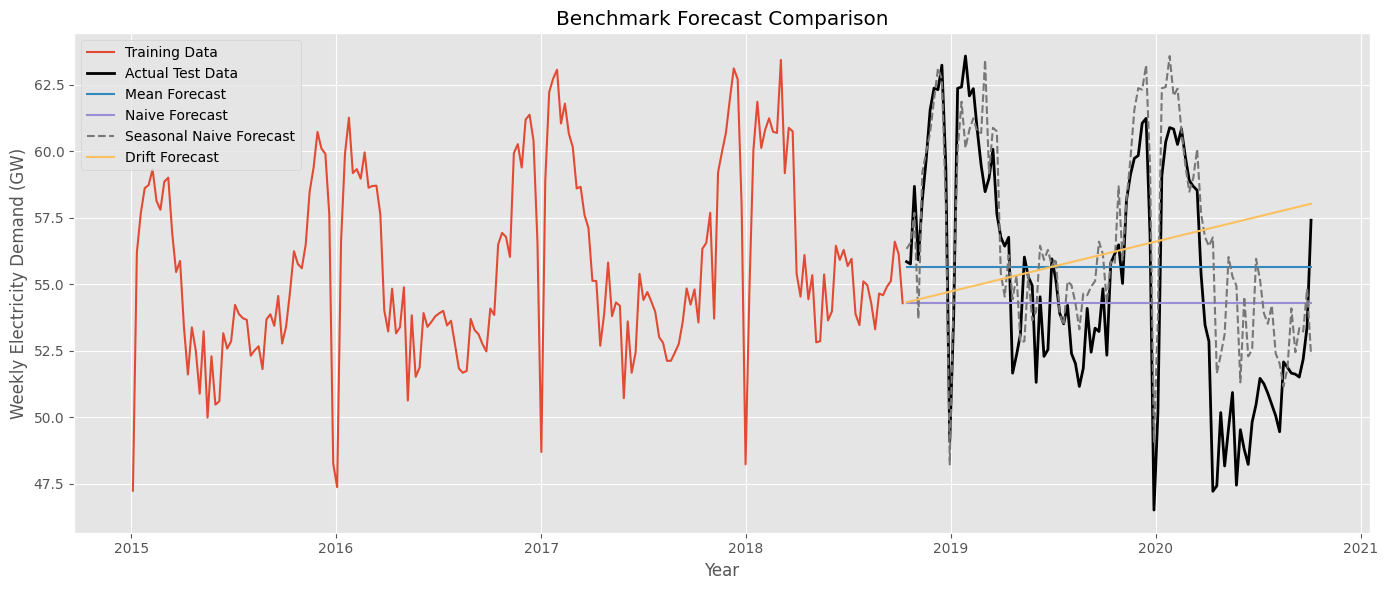

In [21]:
# Benchmark Forecast Comparison

plt.figure(figsize=(14,6))

plt.plot(train.index, train, label="Training Data", linewidth=1.5)
plt.plot(test.index, test, label="Actual Test Data", color="black", linewidth=2)
plt.plot(test.index, mean_forecast, label="Mean Forecast")
plt.plot(test.index, naive_forecast, label="Naive Forecast")
plt.plot(test.index, seasonal_naive_forecast, label="Seasonal Naive Forecast", linestyle="--")
plt.plot(test.index, drift_forecast, label="Drift Forecast")

plt.title("Benchmark Forecast Comparison")
plt.xlabel("Year")
plt.ylabel("Weekly Electricity Demand (GW)")

plt.legend()

plt.tight_layout()

plt.show()

# Seasonal ARIMA (SARIMA) Model

The benchmark analysis indicates that the weekly electricity demand series contains a clear annual seasonal pattern.

To capture both the non-seasonal and seasonal dynamics, a Seasonal Autoregressive Integrated Moving Average (SARIMA) model is employed.

The optimal model parameters are determined through a grid search based on the Akaike Information Criterion (AIC), with the model achieving the lowest AIC selected for forecasting.

In [22]:
# Import Required Libraries

import itertools
import warnings

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.simplefilter("ignore", ConvergenceWarning)

Grid Search (AIC)

In [20]:
# SARIMA Grid Search using AIC

p = range(0,6)
d = range(0,2)
q = range(0,6)

P = range(0,2)
D = range(0,1)
Q = range(0,2)

seasonal_period = 52

best_aic = np.inf
best_order = None
best_seasonal = None

Grid Search Loop

In [ ]:
for order in itertools.product(p, d, q):

    for seasonal in itertools.product(P, D, Q):

        seasonal_order = (
            seasonal[0],
            seasonal[1],
            seasonal[2],
            seasonal_period
        )

        try:

            model = SARIMAX(
                train,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            result = model.fit(
                disp=False,
                maxiter=100
            )

            if result.aic < best_aic:

                best_aic = result.aic
                best_order = order
                best_seasonal = seasonal_order

        except:
            continue

print("Best Order :", best_order)
print("Best Seasonal Order :", best_seasonal)
print("Best AIC :", round(best_aic,2))

Best Order : (0, 1, 3)
Best Seasonal Order : (0, 1, 1, 52)
Best AIC : 314.3


SARIMA Model

In [23]:
# Final SARIMA Model

sarima = SARIMAX(
    train,
    order=(0, 1, 3),
    seasonal_order=(0, 1, 1, 52),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False,
)

sarima_fit = sarima.fit(disp=False)
sarima_fc = sarima_fit.get_forecast(steps=h)
sarima_mean = sarima_fc.predicted_mean
sarima_ci95 = sarima_fc.conf_int(alpha=0.05)
sarima_ci80 = sarima_fc.conf_int(alpha=0.20)

sarima_mean.index = test.index
sarima_ci95.index = test.index
sarima_ci80.index = test.index

results.append(
    evaluate_forecast(
        "SARIMA",
        test,
        sarima_mean,
        train
    )
)

In [24]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("MASE").reset_index(drop=True)

results_df.round(3)

,Model,MAE,RMSE,MASE,Bias
0,Seasonal Naive,2.063,2.672,1.541,1.441
1,SARIMA,2.956,3.638,2.209,2.681
2,Naive,3.783,4.459,2.827,-0.882
3,Mean,3.789,4.397,2.831,0.481
4,Drift,4.340,5.118,3.243,1.007


Forecast the Last 2 Years

In [25]:
# Forecast the Test Period

sarima_fc = sarima_fit.get_forecast(steps=h)

sarima_mean = sarima_fc.predicted_mean

sarima_ci95 = sarima_fc.conf_int(alpha=0.05)
sarima_ci80 = sarima_fc.conf_int(alpha=0.20)

# Match forecast index to test period
sarima_mean.index = test.index
sarima_ci95.index = test.index
sarima_ci80.index = test.index

Evaluate the SARIMA Model

In [26]:
# Evaluate SARIMA Model

sarima_result = evaluate_forecast(
    "SARIMA",
    test,
    sarima_mean,
    train
)

sarima_result = pd.DataFrame([sarima_result])

sarima_result.round(3)

,Model,MAE,RMSE,MASE,Bias
0,SARIMA,2.956,3.638,2.209,2.681


Forecast Plot with Confidence Intervals

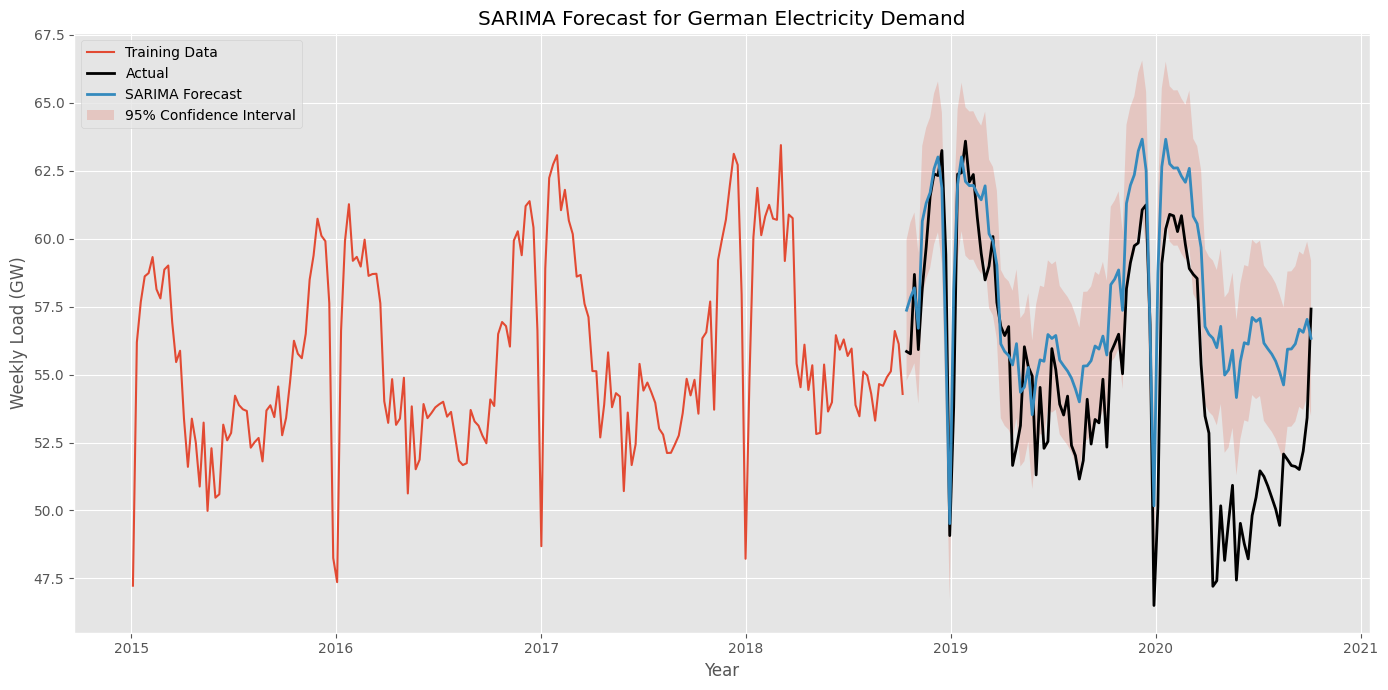

In [27]:
# SARIMA Forecast

plt.figure(figsize=(14,7))

plt.plot(
    train.index,
    train,
    label="Training Data",
    linewidth=1.5
)

plt.plot(
    test.index,
    test,
    color="black",
    linewidth=2,
    label="Actual"
)

plt.plot(
    test.index,
    sarima_mean,
    linewidth=2,
    label="SARIMA Forecast"
)

plt.fill_between(
    test.index,
    sarima_ci95.iloc[:,0],
    sarima_ci95.iloc[:,1],
    alpha=0.20,
    label="95% Confidence Interval"
)

plt.title("SARIMA Forecast for German Electricity Demand")

plt.xlabel("Year")

plt.ylabel("Weekly Load (GW)")

plt.legend()

plt.tight_layout()

plt.show()

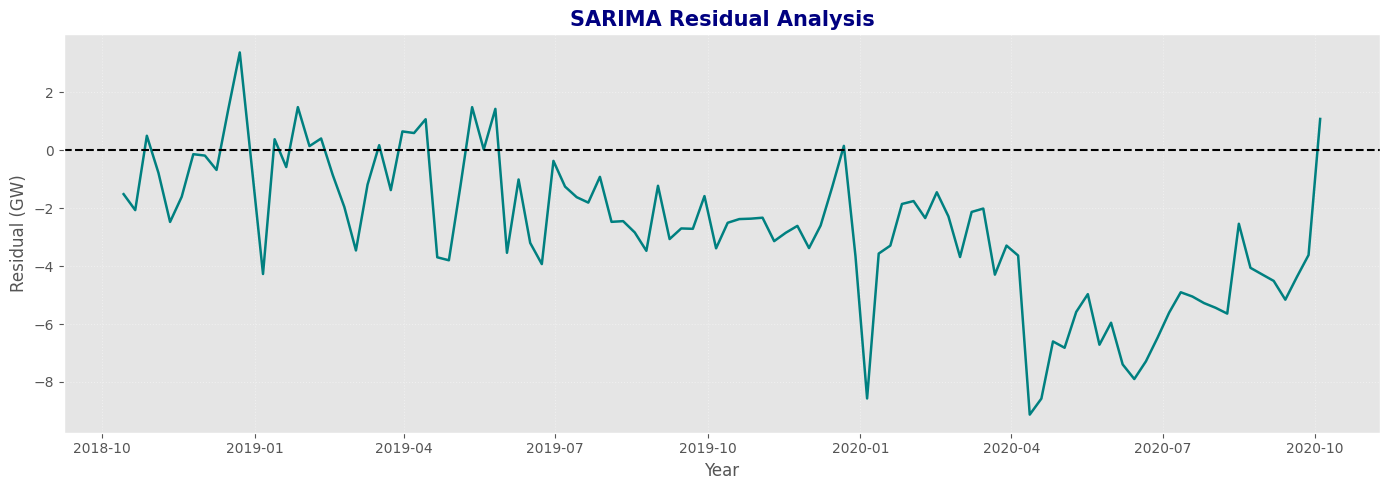

In [28]:
# SARIMA Residual Analysis

sarima_prediction = sarima_fc.predicted_mean
sarima_residuals = test - sarima_prediction

plt.figure(figsize=(14,5))

plt.plot(
    sarima_residuals.index,
    sarima_residuals,
    color="teal",
    linewidth=1.8
)

plt.axhline(
    y=0,
    color="black",
    linestyle="--",
    linewidth=1.5
)

plt.title(
    "SARIMA Residual Analysis",
    fontsize=15,
    fontweight="bold",
    color="navy"
)

plt.xlabel("Year", fontsize=12)
plt.ylabel("Residual (GW)", fontsize=12)

plt.grid(
    linestyle=":",
    alpha=0.4
)

plt.tight_layout()
plt.show()

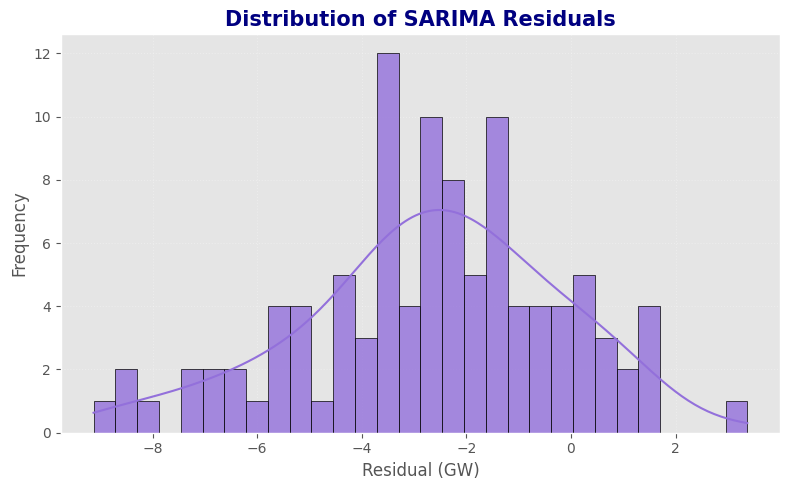

In [29]:
# Distribution of SARIMA Residuals

plt.figure(figsize=(8,5))

sns.histplot(
    sarima_residuals,
    bins=30,
    kde=True,
    color="mediumpurple",
    edgecolor="black",
    alpha=0.8
)

plt.title(
    "Distribution of SARIMA Residuals",
    fontsize=15,
    fontweight="bold",
    color="navy"
)

plt.xlabel("Residual (GW)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.grid(
    linestyle=":",
    alpha=0.3
)

plt.tight_layout()
plt.show()

Residual ACF

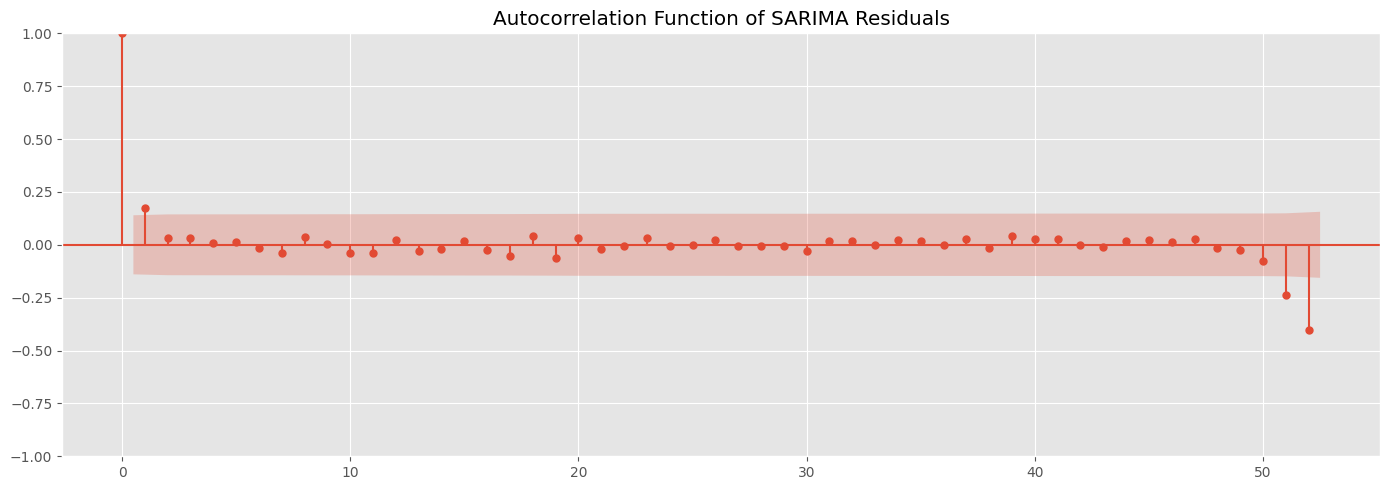

In [30]:
plt.figure(figsize=(14,5))

plot_acf(
    sarima_fit.resid.dropna(),
    lags=52,
    ax=plt.gca()
)

plt.title("Autocorrelation Function of SARIMA Residuals")

plt.tight_layout()

plt.show()

Ljung–Box Test

In [31]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box = acorr_ljungbox(
    sarima_fit.resid.dropna(),
    lags=[20],
    return_df=True
)

ljung_box

,lb_stat,lb_pvalue
20,10.435212,0.959577


Download Temperature Data

In [28]:
# Download Daily Temperature Data (Berlin)

import requests

def get_open_meteo_temperature(
    latitude=52.52,
    longitude=13.41,
    start_date="2015-01-01",
    end_date="2020-10-31",
):

    url = "https://archive-api.open-meteo.com/v1/archive"

    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": start_date,
        "end_date": end_date,
        "daily": "temperature_2m_mean",
        "timezone": "Europe/Berlin",
    }

    response = requests.get(url, params=params)
    response.raise_for_status()

    data = response.json()["daily"]

    temp = pd.DataFrame({
        "date": pd.to_datetime(data["time"]),
        "temperature_2m_mean": data["temperature_2m_mean"],
    })

    temp = temp.set_index("date")

    return temp

Create Weekly Temperature Features

In [29]:
# Weekly Temperature Features

temp_daily = get_open_meteo_temperature(
    start_date=str(load.index.min().date()),
    end_date=str(load.index.max().date()),
)

# Match timezone with electricity data
temp_daily.index = temp_daily.index.tz_localize("UTC")

temp_weekly = pd.DataFrame(index=weekly.index)

temp_weekly["temp_mean"] = temp_daily["temperature_2m_mean"].resample("W").mean()
temp_weekly["temp_min"] = temp_daily["temperature_2m_mean"].resample("W").min()
temp_weekly["temp_max"] = temp_daily["temperature_2m_mean"].resample("W").max()

base_heat = 15.5
base_cool = 22.0

temp_weekly["heating_degree"] = (
    np.maximum(base_heat - temp_daily["temperature_2m_mean"], 0)
    .resample("W")
    .sum()
)

temp_weekly["cooling_degree"] = (
    np.maximum(temp_daily["temperature_2m_mean"] - base_cool, 0)
    .resample("W")
    .sum()
)
# Align exactly with electricity data
temp_weekly = temp_weekly.reindex(weekly.index)

temp_weekly.head()

,temp_mean,temp_min,temp_max,heating_degree,cooling_degree
datetime,,,,,
2015-01-04 00:00:00+00:00,3.575000,2.8,4.6,47.7,0.0
2015-01-11 00:00:00+00:00,3.885714,1.2,8.5,81.3,0.0
2015-01-18 00:00:00+00:00,4.900000,-0.8,9.2,74.2,0.0
2015-01-25 00:00:00+00:00,0.028571,-0.7,0.9,108.3,0.0
2015-02-01 00:00:00+00:00,1.414286,-0.1,2.8,98.6,0.0


Merge Electricity and Temperature Data

In [30]:
# Merge Electricity Load and Temperature Features

feature_df = pd.DataFrame({
    "load_gw": weekly
})

feature_df = feature_df.join(temp_weekly)

feature_df = feature_df.interpolate("time")

feature_df = feature_df.dropna()

feature_df.head()

,load_gw,temp_mean,temp_min,temp_max,heating_degree,cooling_degree
datetime,,,,,,
2015-01-04 00:00:00+00:00,47.233740,3.575000,2.8,4.6,47.7,0.0
2015-01-11 00:00:00+00:00,56.191101,3.885714,1.2,8.5,81.3,0.0
2015-01-18 00:00:00+00:00,57.672679,4.900000,-0.8,9.2,74.2,0.0
2015-01-25 00:00:00+00:00,58.613304,0.028571,-0.7,0.9,108.3,0.0
2015-02-01 00:00:00+00:00,58.734030,1.414286,-0.1,2.8,98.6,0.0


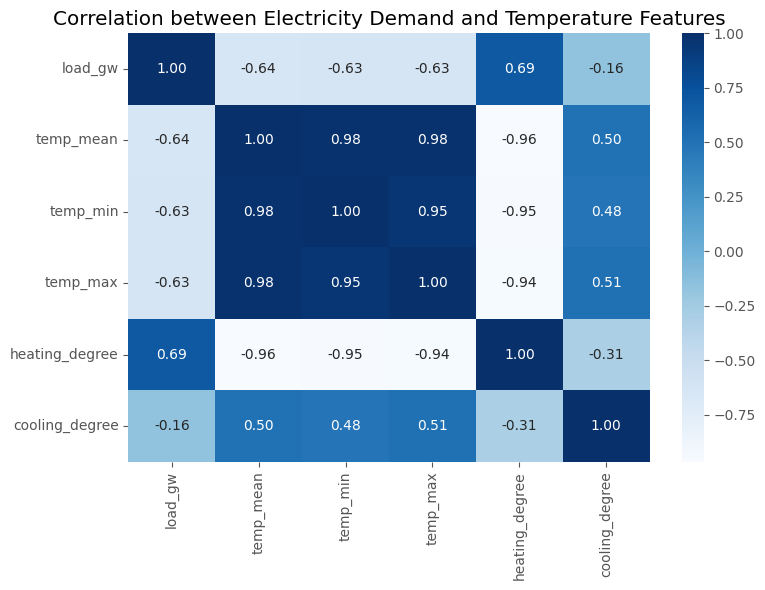

In [31]:
# Correlation Matrix
plt.figure(figsize=(8,6))

sns.heatmap(
    feature_df.corr(),
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation between Electricity Demand and Temperature Features")

plt.tight_layout()

plt.show()

Prepare SARIMAX Dataset

In [32]:
# Prepare Target and Exogenous Variables

y = feature_df["load_gw"]

X = feature_df[
    [
        "temp_mean",
        "heating_degree",
        "cooling_degree"
    ]
]

test_weeks = 104

y_train = y.iloc[:-test_weeks]
y_test = y.iloc[-test_weeks:]

X_train = X.iloc[:-test_weeks]
X_test = X.iloc[-test_weeks:]

Fit SARIMAX

In [33]:
# Fit SARIMAX Model

sarimax_x = SARIMAX(
    y_train,
    exog=X_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 52),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False,
)

sarimax_x_fit = sarimax_x.fit(disp=False)

print(sarimax_x_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                            load_gw   No. Observations:                  197
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 52)   Log Likelihood                -144.353
Date:                            Sat, 11 Jul 2026   AIC                            306.706
Time:                                    07:23:50   BIC                            329.204
Sample:                                01-04-2015   HQIC                           315.779
                                     - 10-07-2018                                         
Covariance Type:                              opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
intercept         -0.0003      0.006     -0.050      0.960      -0.013       0.012
temp_mean          0.23

Forecast

In [34]:
# Generate Forecast

sarimax_x_fc = sarimax_x_fit.get_forecast(
    steps=len(y_test),
    exog=X_test
)

sarimax_x_mean = sarimax_x_fc.predicted_mean

sarimax_x_ci95 = sarimax_x_fc.conf_int(alpha=0.05)

sarimax_x_mean.index = y_test.index
sarimax_x_ci95.index = y_test.index

Evaluate

In [35]:
# Evaluate SARIMAX

sarimax_result = evaluate_forecast(
    "SARIMAX",
    y_test,
    sarimax_x_mean,
    y_train
)

sarimax_result = pd.DataFrame([sarimax_result])

sarimax_result.round(3)

,Model,MAE,RMSE,MASE,Bias
0,SARIMAX,2.828,3.589,2.113,2.6


SARIMAX Forecast

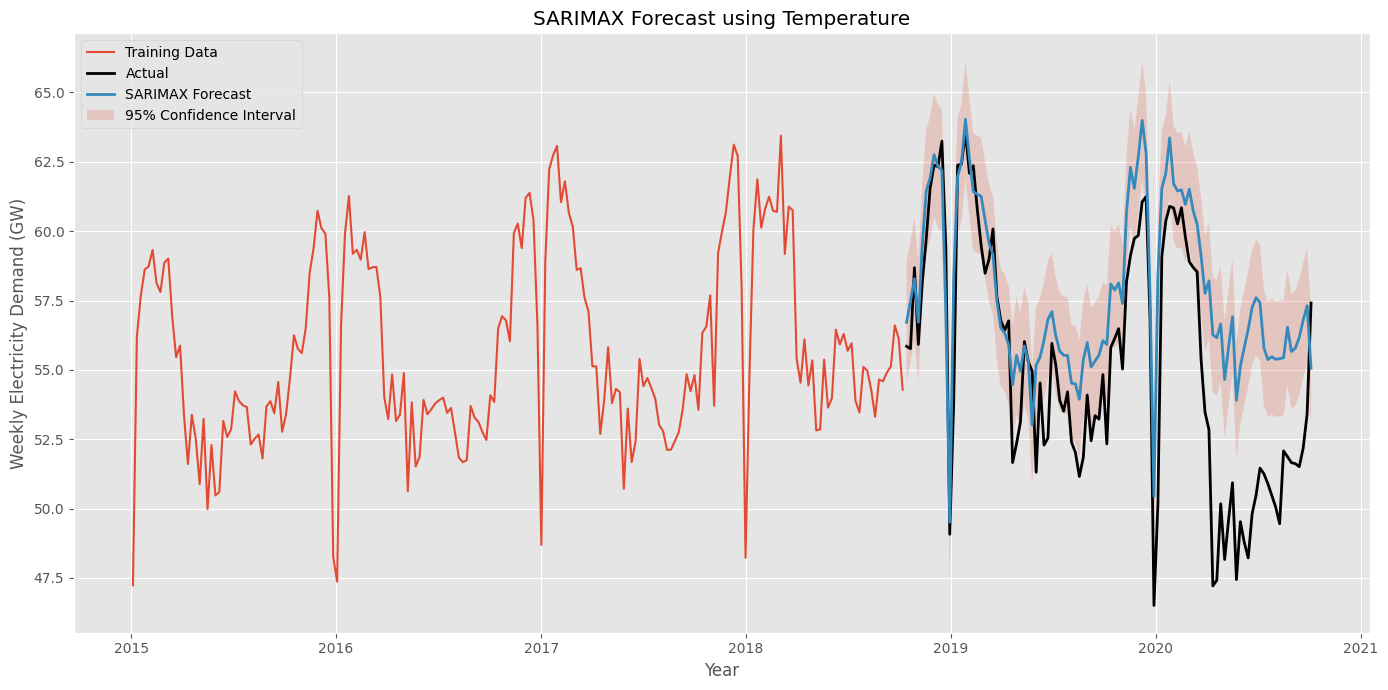

In [36]:
# SARIMAX Forecast

plt.figure(figsize=(14,7))

plt.plot(train.index, train,
         label="Training Data")

plt.plot(y_test.index, y_test,
         color="black",
         linewidth=2,
         label="Actual")

plt.plot(
    sarimax_x_mean,
    linewidth=2,
    label="SARIMAX Forecast"
)

plt.fill_between(
    y_test.index,
    sarimax_x_ci95.iloc[:,0],
    sarimax_x_ci95.iloc[:,1],
    alpha=0.20,
    label="95% Confidence Interval"
)

plt.title("SARIMAX Forecast using Temperature")

plt.xlabel("Year")

plt.ylabel("Weekly Electricity Demand (GW)")

plt.legend()

plt.tight_layout()

plt.show()

In [37]:
# Model Comparison

comparison = benchmark_results.copy()

comparison = pd.concat(
    [
        comparison,
        sarimax_result
    ],
    ignore_index=True
)

comparison = comparison.sort_values("RMSE")

comparison.round(3)

,Model,MAE,RMSE,MASE,Bias
0,Seasonal Naive,2.063,2.672,1.541,1.441
4,SARIMAX,2.828,3.589,2.113,2.600
2,Mean,3.789,4.397,2.831,0.481
1,Naive,3.783,4.459,2.827,-0.882
3,Drift,4.340,5.118,3.243,1.007


Feature-Based Machine Learning Model

In [38]:
# Part 5: Feature-Based Machine Learning Model

from sklearn.ensemble import HistGradientBoostingRegressor

# Create Machine Learning Features
def create_ml_features(data):

    ml_data = data.copy()

    # Lag Features
    lag_periods = [1, 2, 4, 8, 13, 26, 52]

    for lag in lag_periods:
        ml_data[f"lag_{lag}"] = ml_data["load_gw"].shift(lag)

    # Rolling Mean Features
    for window in [4, 13, 52]:
        ml_data[f"rolling_mean_{window}"] = (
            ml_data["load_gw"]
            .shift(1)
            .rolling(window)
            .mean()
        )

    # Calendar Features
    week_number = ml_data.index.isocalendar().week.astype(int)

    ml_data["week"] = week_number
    ml_data["year"] = ml_data.index.year

    # Fourier Seasonal Features
    for order in range(1, 4):
        ml_data[f"sin_{order}"] = np.sin(
            2 * np.pi * order * week_number / 52
        )

        ml_data[f"cos_{order}"] = np.cos(
            2 * np.pi * order * week_number / 52
        )

    return ml_data.dropna()

Create Feature Dataset

In [39]:
ml_dataset = create_ml_features(feature_df)

ml_dataset.head()

,load_gw,temp_mean,temp_min,temp_max,heating_degree,cooling_degree,lag_1,lag_2,lag_4,lag_8,...,rolling_mean_13,rolling_mean_52,week,year,sin_1,cos_1,sin_2,cos_2,sin_3,cos_3
datetime,,,,,,,,,,,,,,,,,,,,,
2016-01-03 00:00:00+00:00,47.364036,0.757143,-8.0,7.8,103.2,0.0,48.253363,57.627857,60.106679,56.496375,...,56.671252,54.741913,53,2016,0.120537,0.992709,0.239316,0.970942,0.354605,0.935016
2016-01-10 00:00:00+00:00,56.615143,-3.314286,-6.9,2.1,131.7,0.0,47.364036,48.253363,59.907333,58.491214,...,56.206598,54.744419,1,2016,0.120537,0.992709,0.239316,0.970942,0.354605,0.935016
2016-01-17 00:00:00+00:00,59.913911,0.257143,-2.6,1.8,106.7,0.0,56.615143,47.364036,57.627857,59.382173,...,56.352797,54.752573,2,2016,0.239316,0.970942,0.464723,0.885456,0.663123,0.748511
2016-01-24 00:00:00+00:00,61.267530,-3.642857,-7.2,2.6,134.0,0.0,59.913911,56.615143,48.253363,60.732667,...,56.635100,54.795674,3,2016,0.354605,0.935016,0.663123,0.748511,0.885456,0.464723
2016-01-31 00:00:00+00:00,59.185089,6.357143,3.6,8.4,64.0,0.0,61.267530,59.913911,47.364036,60.106679,...,57.058451,54.846717,4,2016,0.464723,0.885456,0.822984,0.568065,0.992709,0.120537


Train-Test Split

In [42]:
target_column = "load_gw"

predictor_columns = [
    col for col in ml_dataset.columns
    if col != target_column
]

train_data = ml_dataset.iloc[:-104]
test_data = ml_dataset.iloc[-104:]

X_train = train_data[predictor_columns]
X_test = test_data[predictor_columns]

y_train_ml = train_data[target_column]
y_test_ml = test_data[target_column]

Train Gradient Boosting Model

In [44]:
gb_model = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=500,
    max_leaf_nodes=31,
    min_samples_leaf=20,
    random_state=RANDOM_STATE
)
gb_model.fit(X_train, y_train_ml)

HistGradientBoostingRegressor(learning_rate=0.05, max_iter=500, random_state=42)

Generate Forecast

In [45]:
gb_forecast = pd.Series(
    gb_model.predict(X_test),
    index=y_test_ml.index,
    name="Gradient Boosting"
)

gb_forecast.head()

,Gradient Boosting
datetime,
2018-10-14 00:00:00+00:00,56.151192
2018-10-21 00:00:00+00:00,57.365003
2018-10-28 00:00:00+00:00,57.978207
2018-11-04 00:00:00+00:00,56.015905
2018-11-11 00:00:00+00:00,58.892179


Evaluate Model

In [46]:
gb_result = pd.DataFrame([
    evaluate_forecast(
        "Gradient Boosting",
        y_test_ml,
        gb_forecast,
        train
    )
])

gb_result.round(3)

,Model,MAE,RMSE,MASE,Bias
0,Gradient Boosting,2.039,2.744,1.524,1.329


Forecast Plot

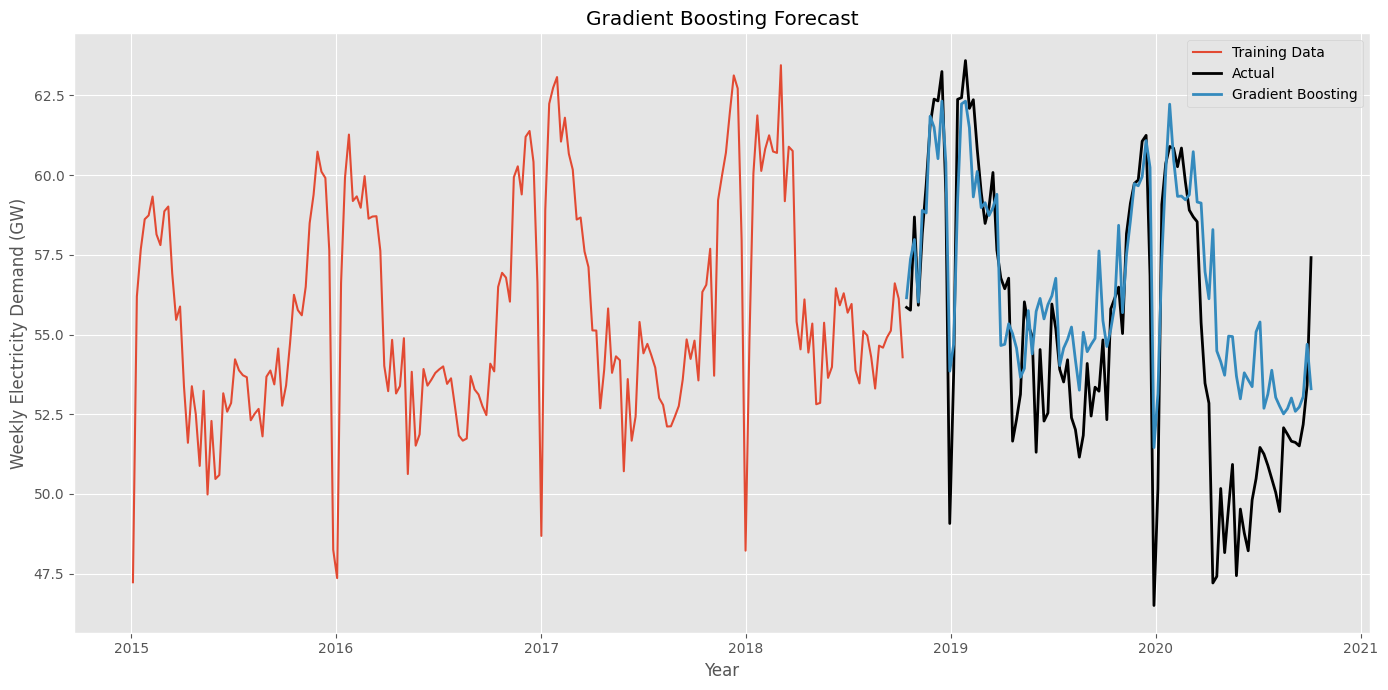

In [47]:
plt.figure(figsize=(14, 7))

plt.plot(train.index, train, label="Training Data")

plt.plot(
    y_test_ml.index,
    y_test_ml,
    color="black",
    linewidth=2,
    label="Actual"
)

plt.plot(
    gb_forecast,
    linewidth=2,
    label="Gradient Boosting"
)

plt.title("Gradient Boosting Forecast")

plt.xlabel("Year")
plt.ylabel("Weekly Electricity Demand (GW)")

plt.legend()

plt.tight_layout()

plt.show()

Compare Models

In [50]:
results_df = pd.concat(
    [
        benchmark_results,
        sarima_result,
        sarimax_result,
        gb_result
    ],
    ignore_index=True
)

results_df = (
    results_df
    .sort_values("RMSE")
    .reset_index(drop=True)
)

results_df.round(3)

,Model,MAE,RMSE,MASE,Bias
0,Seasonal Naive,2.063,2.672,1.541,1.441
1,Gradient Boosting,2.039,2.744,1.524,1.329
2,SARIMAX,2.828,3.589,2.113,2.600
3,SARIMA,2.956,3.638,2.209,2.681
4,Mean,3.789,4.397,2.831,0.481
5,Naive,3.783,4.459,2.827,-0.882
6,Drift,4.340,5.118,3.243,1.007


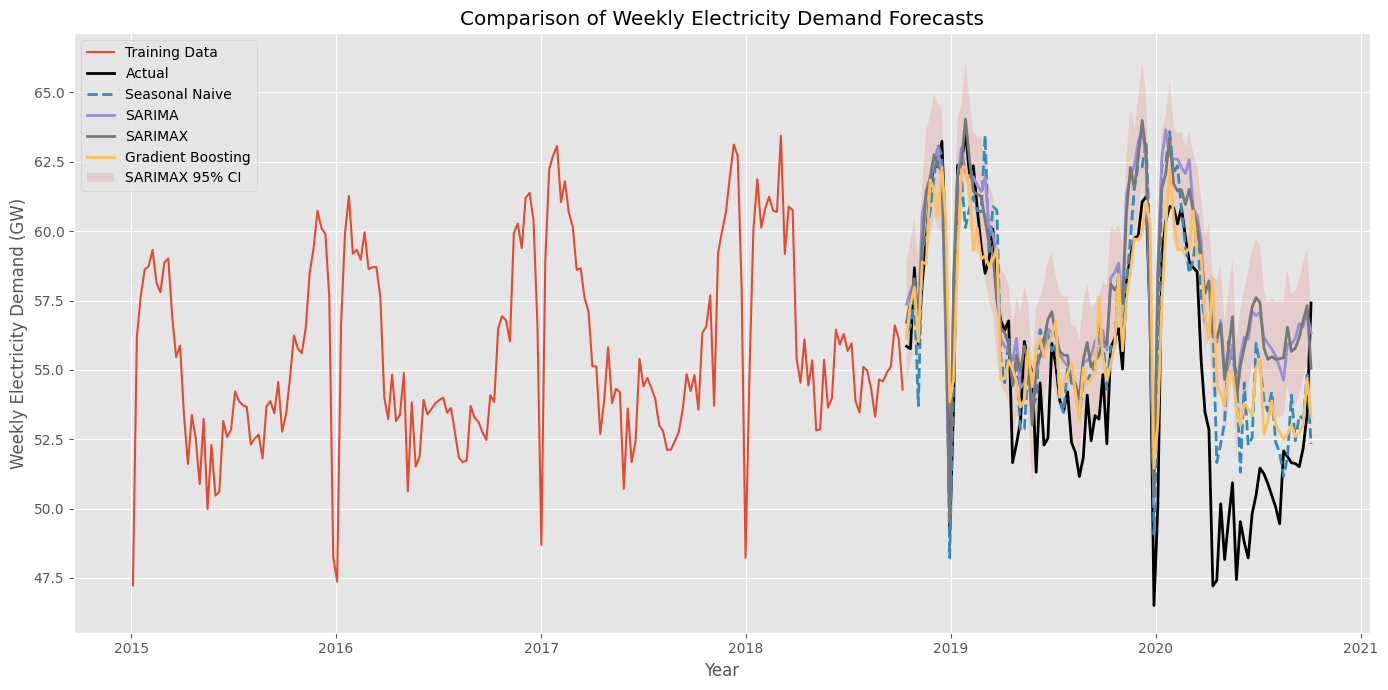

In [51]:
# ------------------------------------------------------------
# Forecast Comparison of Final Models
# ------------------------------------------------------------

plt.figure(figsize=(14, 7))

# Training data
plt.plot(
    train.index,
    train,
    label="Training Data",
    linewidth=1.5
)

# Actual observations
plt.plot(
    test.index,
    test,
    color="black",
    linewidth=2,
    label="Actual"
)

# Seasonal Naive
plt.plot(
    test.index,
    seasonal_naive_forecast,
    linestyle="--",
    linewidth=2,
    label="Seasonal Naive"
)

# SARIMA
plt.plot(
    test.index,
    sarima_mean.reindex(test.index),
    linewidth=2,
    label="SARIMA"
)

# SARIMAX
plt.plot(
    test.index,
    sarimax_x_mean.reindex(test.index),
    linewidth=2,
    label="SARIMAX"
)

# Gradient Boosting
plt.plot(
    test.index,
    gb_forecast.reindex(test.index),
    linewidth=2,
    label="Gradient Boosting"
)

# SARIMAX Confidence Interval
plt.fill_between(
    test.index,
    sarimax_x_ci95.iloc[:, 0],
    sarimax_x_ci95.iloc[:, 1],
    alpha=0.15,
    label="SARIMAX 95% CI"
)

plt.title("Comparison of Weekly Electricity Demand Forecasts")
plt.xlabel("Year")
plt.ylabel("Weekly Electricity Demand (GW)")

plt.legend()
plt.tight_layout()
plt.show()

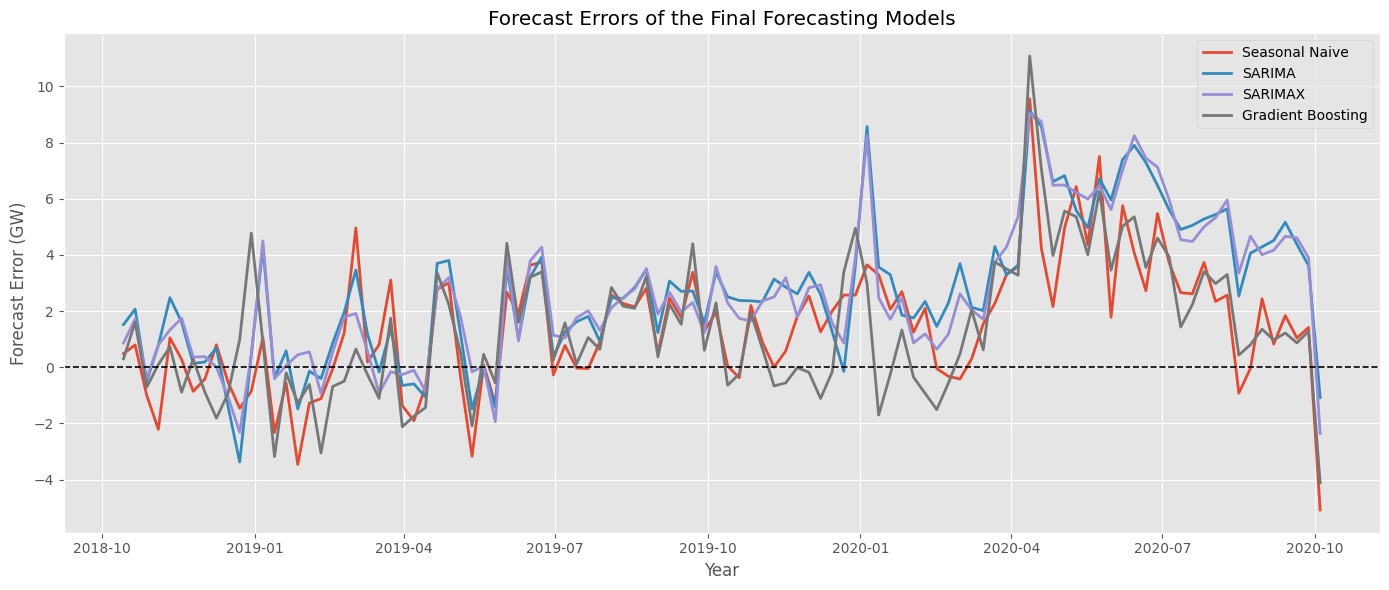

In [52]:
# Residual Diagnostics for Final Forecasting Models

diagnostics = pd.DataFrame({
    "Actual": test,
    "Seasonal Naive": seasonal_naive_forecast,
    "SARIMA": sarima_mean.reindex(test.index),
    "SARIMAX": sarimax_x_mean.reindex(test.index),
    "Gradient Boosting": gb_forecast.reindex(test.index)

})

# Calculate forecast errors
for col in diagnostics.columns[1:]:

    diagnostics[f"{col} Error"] = (
        diagnostics[col] - diagnostics["Actual"]
    )

# Error columns only
error_cols = [
    col for col in diagnostics.columns
    if col.endswith("Error")
]

# Plot forecast errors
plt.figure(figsize=(14, 6))

for col in error_cols:

    plt.plot(
        diagnostics.index,
        diagnostics[col],
        linewidth=2,
        label=col.replace(" Error", "")
    )

plt.axhline(
    y=0,
    color="black",
    linestyle="--",
    linewidth=1.2
)

plt.title("Forecast Errors of the Final Forecasting Models")

plt.xlabel("Year")

plt.ylabel("Forecast Error (GW)")

plt.legend()

plt.tight_layout()

plt.show()

# Long Short-Term Memory (LSTM) Model

Unlike SARIMA and feature-based machine learning models, Long Short-Term Memory (LSTM) networks are capable of learning complex nonlinear relationships and long-term temporal dependencies directly from sequential data.

LSTM networks have been widely applied to electricity demand forecasting because they can effectively capture daily, weekly and seasonal consumption patterns without requiring explicit statistical assumptions.

Following the assignment requirements, the LSTM model is developed using the original hourly German electricity demand data. The final two years of observations are reserved as the test set, while the remaining data are used for training. The model performance is evaluated using the same forecasting metrics as the previous models to enable direct comparison.

Prepare Hourly Data

In [53]:
# Prepare Hourly Electricity Demand Data

hourly = load.copy()
hourly = hourly.asfreq("h")
hourly = hourly.interpolate("time")

hourly.name = "load_mw"

print(hourly.head())

print()

print(hourly.tail())

print()

print("Number of hourly observations :", len(hourly))

datetime
2015-01-01 00:00:00+00:00    41151.0
2015-01-01 01:00:00+00:00    40135.0
2015-01-01 02:00:00+00:00    39106.0
2015-01-01 03:00:00+00:00    38765.0
2015-01-01 04:00:00+00:00    38941.0
Freq: h, Name: load_mw, dtype: float64

datetime
2020-09-30 19:00:00+00:00    57559.0
2020-09-30 20:00:00+00:00    54108.0
2020-09-30 21:00:00+00:00    49845.0
2020-09-30 22:00:00+00:00    46886.0
2020-09-30 23:00:00+00:00    45461.0
Freq: h, Name: load_mw, dtype: float64

Number of hourly observations : 50400


Train/Test Split

In [54]:
test_hours = 24 * 365 * 2

train_hourly = hourly.iloc[:-test_hours]

test_hourly = hourly.iloc[-test_hours:]

print(train_hourly.index.min(), train_hourly.index.max())

print(test_hourly.index.min(), test_hourly.index.max())

2015-01-01 00:00:00+00:00 2018-10-01 23:00:00+00:00
2018-10-02 00:00:00+00:00 2020-09-30 23:00:00+00:00


## Data Scaling

Neural networks are sensitive to the scale of the input data. Therefore, the hourly electricity demand is normalised using Min-Max scaling.

To prevent information leakage, the scaler is fitted only on the training data and then applied to the test data using the same transformation.

In [55]:
# Scale the Hourly Data

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(
    train_hourly.values.reshape(-1, 1)
)
test_scaled = scaler.transform(
    test_hourly.values.reshape(-1, 1)
)

print(train_scaled.shape)
print(test_scaled.shape)

(32880, 1)
(17520, 1)


Create Supervised Learning Sequences

In [56]:
# Convert Time Series into Supervised Sequences

LOOKBACK = 168      # previous 7 days

def create_sequences(data, lookback):

    X = []
    y = []

    for i in range(lookback, len(data)):

        X.append(data[i-lookback:i, 0])
        y.append(data[i, 0])

    X = np.array(X)
    y = np.array(y)

    return X, y


X_train, y_train = create_sequences(
    train_scaled,
    LOOKBACK
)

X_test, y_test = create_sequences(
    test_scaled,
    LOOKBACK
)

print(X_train.shape)
print(X_test.shape)

(32712, 168)
(17352, 168)


In [57]:
X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

print(X_train.shape)
print(X_test.shape)

(32712, 168, 1)
(17352, 168, 1)


Imports



In [58]:
import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout
)

tf.random.set_seed(RANDOM_STATE)

## LSTM Network Architecture

A deep stacked Long Short-Term Memory (LSTM) network is developed to model the hourly electricity demand.

The architecture was selected to capture both short-term and long-term temporal dependencies present in the hourly electricity demand data.

Build Model

In [59]:
# Deep Stacked LSTM Model

lstm_model = Sequential()

# First LSTM Layer
lstm_model.add(
    LSTM(
        128,
        return_sequences=True,
        input_shape=(LOOKBACK, 1)
    )
)
lstm_model.add(Dropout(0.30))

# Second LSTM Layer
lstm_model.add(
    LSTM(
        64,
        return_sequences=True
    )
)
lstm_model.add(Dropout(0.30))

# Third LSTM Layer
lstm_model.add(
    LSTM(
        32
    )
)
lstm_model.add(Dropout(0.20))

# Dense Layers
lstm_model.add(Dense(32, activation="relu"))
lstm_model.add(Dense(16, activation="relu"))

# Output Layer
lstm_model.add(Dense(1))

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 168, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 168, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 168, 64)        │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 168, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,985 (507.75 KB)

 Trainable params: 129,985 (507.75 KB)

 Non-trainable params: 0 (0.00 B)

Compile

In [61]:
lstm_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

Train

In [62]:
history = lstm_model.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=30,
    batch_size=128,
    verbose=1,
    shuffle=False
)

Epoch 1/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - loss: 0.0436 - mae: 0.1738 - val_loss: 0.0175 - val_mae: 0.1043
Epoch 2/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.0104 - mae: 0.0785 - val_loss: 0.0145 - val_mae: 0.0862
Epoch 3/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.0071 - mae: 0.0636 - val_loss: 0.0101 - val_mae: 0.0750
Epoch 4/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - loss: 0.0054 - mae: 0.0551 - val_loss: 0.0077 - val_mae: 0.0690
Epoch 5/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 0.0045 - mae: 0.0509 - val_loss: 0.0082 - val_mae: 0.0705
Epoch 6/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.0042 - mae: 0.0490 - val_loss: 0.0055 - val_mae: 0.0594
Epoch 7/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 0.0036 - mae: 0.0459 - val_loss: 0.0059 - val_mae: 0.0629
Epoch 8/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.0033 - mae: 0.0440 - val_loss: 0.0052 - val_mae: 0.0590
Epoch 9/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 6s 30m

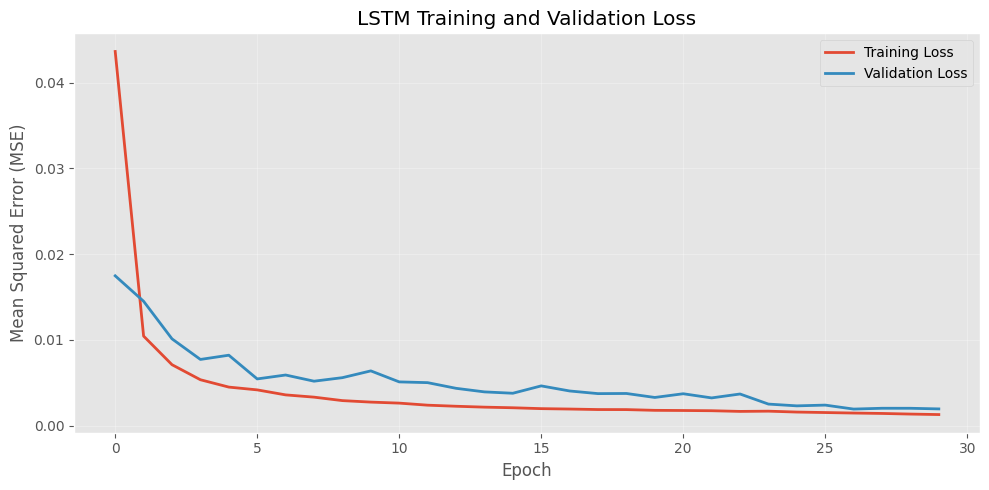

In [63]:
# Training and Validation Loss


plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    linewidth=2,
    label="Validation Loss"
)

plt.title("LSTM Training and Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Mean Squared Error (MSE)")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [65]:
# Generate LSTM Predictions

lstm_pred_scaled = lstm_model.predict(
    X_test,
    verbose=1
)

543/543 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step


In [66]:
# Inverse Scaling
# Convert Back to Original Scale


lstm_pred = scaler.inverse_transform(
    lstm_pred_scaled
)

y_test_actual = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

In [67]:
# Create Forecast Series

lstm_forecast = pd.Series(

    lstm_pred.flatten(),

    index=test_hourly.index[LOOKBACK:],

    name="LSTM"

)

actual_hourly = pd.Series(

    y_test_actual.flatten(),

    index=test_hourly.index[LOOKBACK:]

)

In [68]:
# LSTM Performance

lstm_result = evaluate_forecast(

    "LSTM",

    actual_hourly,

    lstm_forecast,

    train_hourly

)

lstm_result = pd.DataFrame([lstm_result])

lstm_result.round(3)

,Model,MAE,RMSE,MASE,Bias
0,LSTM,1590.896,2113.366,0.15,-1208.677


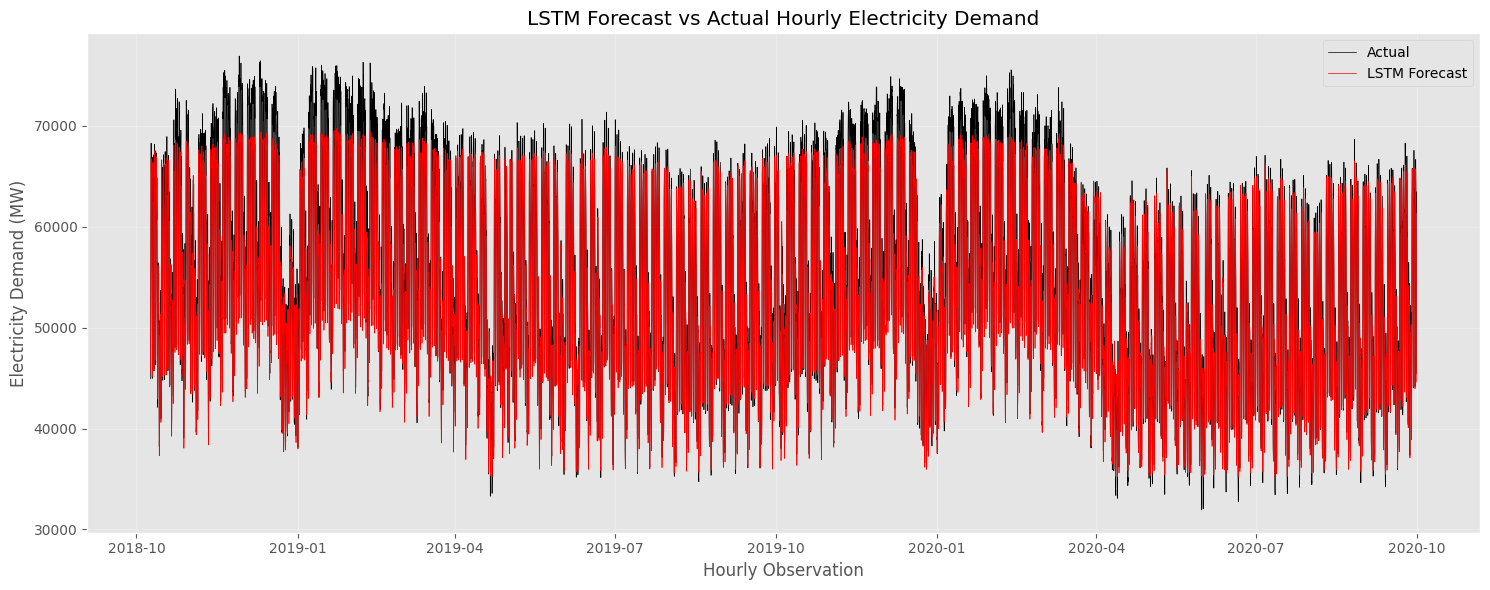

In [74]:
# LSTM Forecast vs Actual Electricity Demand

plt.figure(figsize=(15, 6))

plt.plot(
    actual_hourly,
    color="black",
    linewidth=0.5,
    label="Actual"
)

plt.plot(
    lstm_forecast,
    color="red",
    linewidth=0.5,
    label="LSTM Forecast"
)

plt.title("LSTM Forecast vs Actual Hourly Electricity Demand")

plt.xlabel("Hourly Observation")

plt.ylabel("Electricity Demand (MW)")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

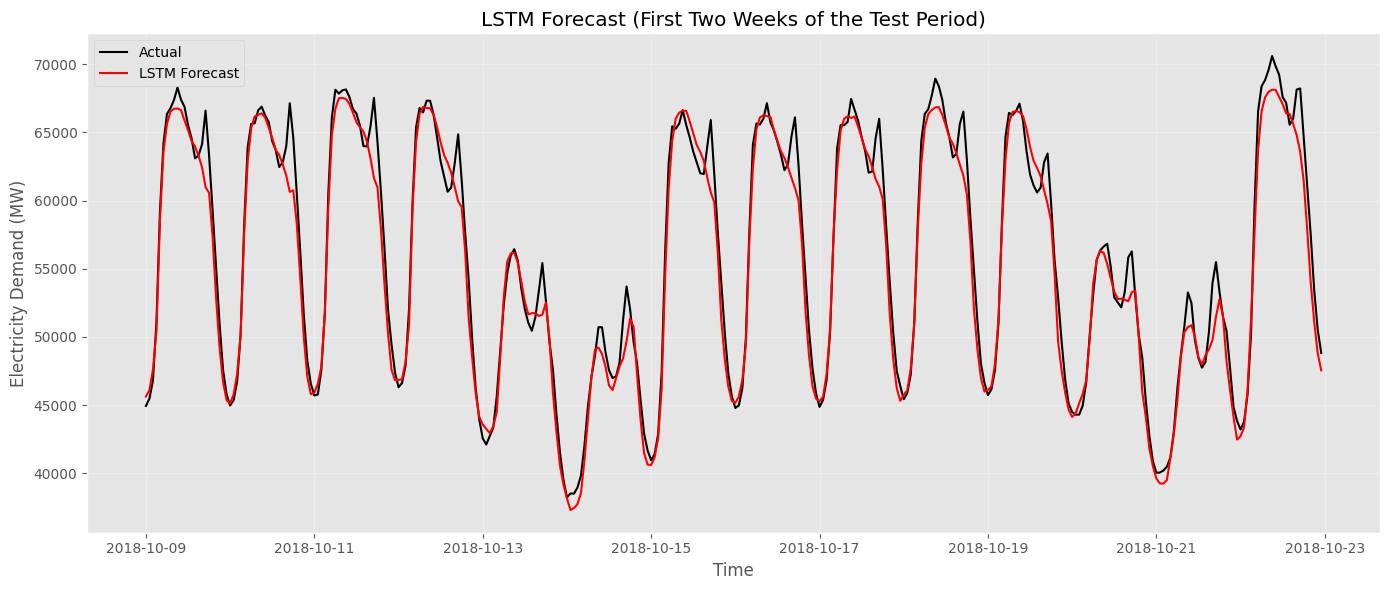

In [75]:
# LSTM Forecast (First Two Weeks of Test Period)


hours_to_plot = 24 * 14      # First 14 days

plt.figure(figsize=(14, 6))

plt.plot(
    actual_hourly.iloc[:hours_to_plot],
    color="black",
    linewidth=1.5,
    label="Actual"
)

plt.plot(
    lstm_forecast.iloc[:hours_to_plot],
    color="red",
    linewidth=1.5,
    label="LSTM Forecast"
)

plt.title("LSTM Forecast (First Two Weeks of the Test Period)")

plt.xlabel("Time")

plt.ylabel("Electricity Demand (MW)")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

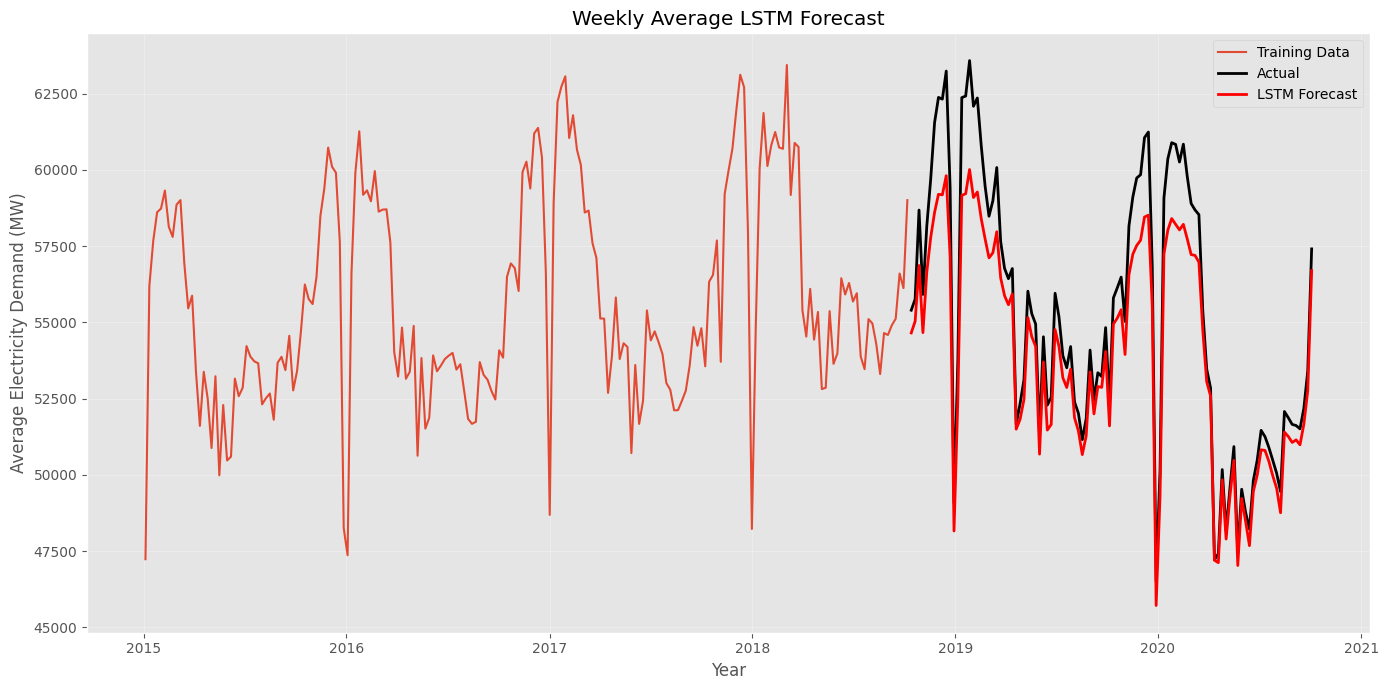

In [76]:
# Weekly Average LSTM Forecast

# Actual hourly values -> Weekly average
actual_weekly = (
    pd.Series(
        y_test_actual.flatten(),
        index=actual_hourly.index
    )
    .resample("W")
    .mean()
)

# LSTM hourly predictions -> Weekly average
forecast_weekly = (
    pd.Series(
        lstm_pred.flatten(),
        index=actual_hourly.index
    )
    .resample("W")
    .mean()
)

# Training hourly data -> Weekly average
train_weekly = (
    train_hourly
    .resample("W")
    .mean()
)

# Plot
plt.figure(figsize=(14,7))

plt.plot(
    train_weekly,
    label="Training Data",
    linewidth=1.5
)

plt.plot(
    actual_weekly,
    color="black",
    linewidth=2,
    label="Actual"
)

plt.plot(
    forecast_weekly,
    color="red",
    linewidth=2,
    label="LSTM Forecast"
)

plt.title("Weekly Average LSTM Forecast")

plt.xlabel("Year")

plt.ylabel("Average Electricity Demand (MW)")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

Final Models Comparison

In [77]:
results_df = pd.concat(

    [

        benchmark_results,

        sarima_result,

        sarimax_result,

        gb_result,

        lstm_result

    ],

    ignore_index=True

)

results_df = (

    results_df

    .sort_values("RMSE")

    .reset_index(drop=True)

)

results_df.round(3)

,Model,MAE,RMSE,MASE,Bias
0,Seasonal Naive,2.063,2.672,1.541,1.441
1,Gradient Boosting,2.039,2.744,1.524,1.329
2,SARIMAX,2.828,3.589,2.113,2.600
3,SARIMA,2.956,3.638,2.209,2.681
4,Mean,3.789,4.397,2.831,0.481
5,Naive,3.783,4.459,2.827,-0.882
6,Drift,4.340,5.118,3.243,1.007
7,LSTM,1590.896,2113.366,0.150,-1208.677
